In [18]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation,FFMpegWriter
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns

# Simulacion general

In [51]:
@njit(parallel=True, fastmath=True)
def actualizar_campos(presion_adversa, u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):
    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] +
                                       p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)
    
    # Gradiente de presión controlado
    for j in prange(nx):
        x = j * dx_star
        for i in prange(ny):
            if x <= 0.3:
                p_star[i, j] += 0.01  # presión constante en entrada
            else:
                p_star[i, j] += presion_adversa * (x - 0.3)


    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y +
                                       (1 / (Re * Pr)) * (diff_T_x + diff_T_y) +
                                       viscous_heating)

    tau = np.zeros((ny, nx))
    for i in prange(1, ny - 1):
        for j in prange(nx):
            tau[i, j] = (u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star)

# Condiciones de frontera
    v_star[0, :] = 0
    v_star[-1, :] = 0
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    u_star[:, -1] = u_star[:, -2]
    p_star[:, 0] = p_star[:, 1]
    p_star[:, -1] = p_star[:, -2]
    p_star[0, :] = p_star[1, :]
    p_star[-1, :] = p_star[-2, :]

    return u_star, v_star, p_star, T_star, tau

def run_asimilacion_general(nx=25, ny=25, observaciones_dict=None,
                            metodo_asimilacion=None,  # función que modifica los campos
                            variables_asimilar=['T'], alpha=0.3,
                            guardar_en_disco=False, folder='DA_output',
                            presion_adversa=0.3):
    """
    Ejecuta una simulación con la posibilidad de aplicar asimilación en ciertas variables.
    El método de asimilación es una función que recibe el estado y modifica las variables indicadas.

    Parámetros:
    -----------
    - observaciones_dict: dict con datos observacionales
    - metodo_asimilacion: función f(u, v, p, T, tau, obs, n) -> dict con claves a modificar
    - variables_asimilar: lista de nombres de variables a asimilar
    """

    # === Setup ===
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt
    save_interval = max(1, nt // 300)

    # Malla
    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Inicialización
    u0, up = 1.0, -1.0
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.ones((ny, nx)) * 0.0
    u_star[0, :] = up
    u_star[-1, :] = u0

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()

        # === Actualizar campos por ecuaciones ===
        u_star, v_star, p_star, T_star, tau = actualizar_campos(presion_adversa,
            u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny)

        # === Aplicar asimilación si corresponde ===
        if metodo_asimilacion is not None and observaciones_dict is not None:
            estado = {'u': u_star, 'v': v_star, 'p': p_star, 'T': T_star, 'tau': tau}
            obs_n = {k: v[n] for k, v in observaciones_dict.items() if k in variables_asimilar and len(v) > n}
            correccion = metodo_asimilacion(estado, obs_n, n, alpha)

            for var in correccion:
                if var in estado:
                    estado[var][:] = correccion[var]

        # === Guardar ===
        if n % save_interval == 0 or n == nt - 1:
            u_hist.append(u_star.copy())
            v_hist.append(v_star.copy())
            p_hist.append(p_star.copy())
            T_hist.append(T_star.copy())
            tau_hist.append(tau.copy())

    print("✅ Asimilación finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "save_interval": save_interval
        },
        "X_star": X_star,
        "Y_star": Y_star
    }


# Funciones auxiliares

In [52]:
def extraer_observaciones(N_sens=10, T_sens=5, size=800, carpeta="sim_separacion", ruido_std=0.0, seed=None):
    """
    Extrae observaciones de temperatura, presión y esfuerzo cortante desde una simulación.

    Parámetros:
    - N_sens: número de sensores a lo largo de x (en y ≈ 0)
    - T_sens: número de frames a extraer
    - size: tamaño del dominio (e.g. 800 para 800x800)
    - carpeta: carpeta donde se encuentran los datos
    - ruido_std: desviación estándar del ruido (gaussiano)
    - seed: semilla para reproducibilidad (opcional)

    Retorna:
    - Lista de diccionarios con observaciones por frame
    """

    if seed is not None:
        np.random.seed(seed)

    # Cargar datos
    path = os.path.join(carpeta, f"{size}x{size}.pkl")
    with open(path, "rb") as f:
        datos = pickle.load(f)

    T_hist = datos["T_history"]
    p_hist = datos["p_history"]
    tau_hist = datos["tau_history"]
    Y_star = datos["Y_star"]

    # Encontrar índice más cercano a y = 0.001
    y_fila = Y_star[:, 0]
    y_idx = int(np.argmin(np.abs(y_fila - 0.001)))  # entero

    nt = len(T_hist)
    x_physical = np.linspace(0, 1, N_sens)
    frame_indices = np.linspace(0, nt - 1, T_sens, dtype=int)

    observaciones = []
    for t in frame_indices:
        T_line = T_hist[t][y_idx, :]
        p_line = p_hist[t][y_idx, :]
        tau_line = tau_hist[t][y_idx, :]
        nx = T_line.shape[0]

        x_idx = (x_physical * (nx - 1)).astype(int)

        obs_t = {
            "t": t,
            "x_phys": x_physical,
            "T": T_line[x_idx].copy(),
            "p": p_line[x_idx].copy(),
            "tau": tau_line[x_idx].copy()
        }

        if ruido_std > 0.0:
            obs_t["T"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["p"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["tau"] += np.random.normal(0, ruido_std, size=N_sens)

        observaciones.append(obs_t)

    return observaciones

def guardar_resultado_asimilacion(resultado, nombre_metodo, carpeta_salida="DA/25x25", metadatos=None):
    """
    Guarda el resultado de un método de asimilación en un archivo .pkl con nombre descriptivo.

    Parámetros:
    -----------
    resultado : dict
        Diccionario con los resultados del método de asimilación.

    nombre_metodo : str
        Nombre del método de asimilación (e.g., "nudging", "kf", "enkf", "4dvar").

    carpeta_salida : str
        Carpeta donde guardar el archivo. Se creará si no existe.

    metadatos : dict
        Diccionario opcional con información adicional, por ejemplo:
        {
            "nx": 25,
            "ny": 25,
            "observaciones": 10,
            "variables_asimiladas": ['T', 'p']
        }
    """
    os.makedirs(carpeta_salida, exist_ok=True)

    # Generar nombre del archivo
    nombre_archivo = nombre_metodo.lower()

    if metadatos is not None:
        if "nx" in metadatos and "ny" in metadatos:
            nombre_archivo += f"_{metadatos['nx']}x{metadatos['ny']}"
        if "n_sensores" in metadatos:
            nombre_archivo += f"_sens{metadatos['n_sensores']}"
        if "n_frames_obs" in metadatos:
            nombre_archivo += f"_frames{metadatos['n_frames_obs']}"
        if "observaciones" in metadatos:
            nombre_archivo += f"_obs{metadatos['observaciones']}"
        if "variables_asimiladas" in metadatos:
            vars_str = ''.join(sorted([v.lower()[0] for v in metadatos['variables_asimiladas']]))
            nombre_archivo += f"_vars{vars_str}"

    nombre_archivo += ".pkl"
    ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

    # Guardar
    with open(ruta_completa, "wb") as f:
        pickle.dump(resultado, f)

    print(f"✅ Guardado: {ruta_completa}")


# Nudging

In [53]:
# ========================NUDGING========================

def run_nudging(nx=25, ny=25, 
                observaciones_dict=None,
                variables_asimilar=['T'],
                seed=None,
                presion_adversa=0.3, 
                alpha=0.3
                ):
    """    Simulación con nudging para asimilación de datos.
    Parámetros:
    - nx, ny: resolución de la malla
    - presion_adversa: presión adversa aplicada en la entrada
    - observaciones_dict: diccionario con observaciones por timestep
    - variables_asimilar: lista de variables a asimilar (e.g. ['T', 'p', 'tau'])
    - alpha: factor de nudging
    Retorna:
    - diccionario con resultados de la simulación
    """

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u0, up = 1.0, -1.0
    T0_star, T1_star = 0.0, 0.0
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.ones((ny, nx)) * T1_star
    u_star[0, :] = up
    u_star[-1, :] = u0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    save_interval = max(1, nt // 300)
    frame_folder = None

    total_nudging_time = 0.0  # antes del bucle

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        # Aplicar Nudging si hay observaciones en este paso
        if observaciones_dict is not None and n in observaciones_dict:
            t0 = time.time()
            obs_t = observaciones_dict[n]
            if 'T' in variables_asimilar:
                T_star = aplicar_nudging(T_star, obs_t, 'T', alpha, nx, ny)
            if 'p' in variables_asimilar:
                p_star = aplicar_nudging(p_star, obs_t, 'p', alpha, nx, ny)
            if 'tau' in variables_asimilar:
                tau = aplicar_nudging(tau, obs_t, 'tau', alpha, nx, ny)

            total_nudging_time += time.time() - t0

        if n % save_interval == 0 or n == nt - 1:
            print(f"\rPaso {n}/{nt}", end="")
            u_hist.append(u_star.copy())
            v_hist.append(v_star.copy())
            p_hist.append(p_star.copy())
            T_hist.append(T_star.copy())
            tau_hist.append(tau.copy())

    print("\n✅ Simulación con nudging finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa, "nudging_alpha": alpha,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_nudging_time,
    }


def aplicar_nudging(campo_modelo, observaciones, variable, alpha, nx, ny):
    """    Aplica el nudging al campo_modelo en y=0 usando observaciones puntuales.
    Parámetros:
    - campo_modelo: campo actual del modelo (e.g. T_star, p_star, tau)
    - observaciones: dict con 'x_phys' y 'variable' (e.g. 'T', 'p', 'tau')
    - variable: nombre de la variable a asimilar ('T', 'p', 'tau')
    - alpha: factor de nudging
    - nx, ny: dimensiones de la malla
    Retorna:
    - campo_actualizado: campo del modelo actualizado con nudging
    """
    
    x_idx = (observaciones["x_phys"] * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # sensores están en y=0
    campo_obs = observaciones[variable]

    campo_actualizado = campo_modelo.copy()
    for xi, yi, obs_val in zip(x_idx, y_idx, campo_obs):
        campo_actualizado[yi, xi] += alpha * (obs_val - campo_modelo[yi, xi])

    return campo_actualizado

# Kalman Filter

In [54]:
def run_kf(nx=25, ny=25, 
            observaciones_dict=None,
            variables_asimilar=['T'],
            seed=None,
            presion_adversa=0.3,
            sigma_obs=0.01, sigma_modelo=1e-4):
    """
    Simulación con filtro de Kalman para asimilación de datos.
    variables_asimilar: lista con 'T', 'p', 'tau'
    sigma_obs: desviación estándar del ruido de observación
    sigma_modelo: varianza asumida del modelo
    """

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u_star = np.ones((ny, nx))
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx))
    tau = np.zeros((ny, nx))

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_kalman_time = 0.0

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        if observaciones_dict is not None and n in observaciones_dict:
            obs = observaciones_dict[n]
            t0 = time.time()

            for var in variables_asimilar:
                campo_modelo = {'T': T_star, 'p': p_star, 'tau': tau}[var]
                campo_corregido = aplicar_kalman_update(
                    campo_modelo,
                    observaciones=obs[var],
                    x_phys=obs["x_phys"],
                    nx=nx, ny=ny,
                    sigma_obs=sigma_obs,
                    sigma_modelo=sigma_modelo
                )
                if var == 'T':
                    T_star = campo_corregido
                elif var == 'p':
                    p_star = campo_corregido
                elif var == 'tau':
                    tau = campo_corregido

            total_kalman_time += time.time() - t0

        u_hist.append(u_star.copy())
        v_hist.append(v_star.copy())
        p_hist.append(p_star.copy())
        T_hist.append(T_star.copy())
        tau_hist.append(tau.copy())

    print("✅ Simulación con Kalman finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "kalman_sigma_obs": sigma_obs,
            "kalman_sigma_modelo": sigma_modelo,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_kalman_time,
    }

def aplicar_kalman_update(campo_modelo, observaciones, x_phys, nx, ny, sigma_obs, sigma_modelo):
    """
    Corrige el campo_modelo en y=0 con observaciones puntuales usando Kalman filter clásico.

    Parámetros:
    -----------
    campo_modelo : 2D np.array
        Campo de la variable (por ejemplo, T, p o tau).

    observaciones : 1D np.array
        Valores observados en los sensores.

    x_phys : 1D np.array
        Posiciones físicas (entre 0 y 1) donde están los sensores.

    nx, ny : int
        Tamaño del dominio.

    sigma_obs : float
        Desviación estándar del ruido en la observación.

    sigma_modelo : float
        Desviación estándar del error de predicción del modelo.

    Retorna:
    --------
    campo_corregido : 2D np.array
        Campo corregido tras aplicar el filtro de Kalman.
    """
    campo_corregido = campo_modelo.copy()
    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)

    # Estado previo (predicción del modelo) en las ubicaciones de los sensores
    x_fondo = campo_modelo[y_idx, x_idx]

    # Matrices del filtro de Kalman (estado observado directamente)
    H = np.eye(len(x_idx))
    R = np.eye(len(x_idx)) * sigma_obs**2
    P = np.eye(len(x_idx)) * sigma_modelo**2

    # Ganancia de Kalman
    K = P @ np.linalg.inv(H @ P @ H.T + R)

    # Actualización del estado
    x_actualizado = x_fondo + K @ (observaciones - H @ x_fondo)

    # Actualizar el campo completo en las posiciones de los sensores
    for xi, yi, val in zip(x_idx, y_idx, x_actualizado):
        campo_corregido[yi, xi] = val

    return campo_corregido


# Ensemble Kalman Filter

In [55]:
def run_enkf(nx=25, ny=25, 
             observaciones_dict=None,
             variables_asimilar=['T'],
             seed=None,
             presion_adversa=0.3,
             N_ens=10, 
             sigma_obs=0.01, sigma_modelo=1e-4):
    """    Simulación con EnKF para asimilación de datos.
    Parámetros:
    - nx, ny: resolución de la malla
    - N_ens: número de miembros del ensamble
    - guardar_en_disco: si True, guarda los frames en disco
    - folder: carpeta donde guardar los resultados
    - presion_adversa: presión adversa aplicada en la entrada
    - observaciones_dict: diccionario con observaciones por timestep
    - variables_asimilar: lista de variables a asimilar (e.g. ['T', 'p', 'tau'])
    - sigma_obs: desviación estándar del ruido de observación
    - seed: semilla para reproducibilidad (opcional)
    Retorna:
    - diccionario con resultados de la simulación
    """

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Inicialización del ensamble
    def crear_estado_inicial():
        u_star = np.ones((ny, nx)) * 1.0
        v_star = np.zeros((ny, nx))
        p_star = np.zeros((ny, nx))
        T_star = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))

        u_star[0, :] = -0.5
        u_star[-1, :] = 1.0
        T_star[0, :] = 0.0
        T_star[-1, :] = 0.0

        return u_star, v_star, p_star, T_star, tau

    ensamble = []
    for _ in range(N_ens):
        u, v, p, T, tau = crear_estado_inicial()
        ensamble.append({'u': u, 'v': v, 'p': p, 'T': T, 'tau': tau})

    # Historial de la media del ensamble
    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        for k in range(N_ens):
            u, v, p, T, tau = ensamble[k]['u'], ensamble[k]['v'], ensamble[k]['p'], ensamble[k]['T'], ensamble[k]['tau']
            u_new, v_new, p_new, T_new, tau_new = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            ensamble[k] = {'u': u_new, 'v': v_new, 'p': p_new, 'T': T_new, 'tau': tau_new}

        if observaciones_dict is not None and n in observaciones_dict:
            t0 = time.time()
            obs = observaciones_dict[n]

            for var in variables_asimilar:
                ensamble = aplicar_enkf_update(
                    ensamble=ensamble,
                    obs=obs,
                    var=var,
                    x_phys=obs['x_phys'],
                    nx=nx,
                    ny=ny,
                    sigma_obs=sigma_obs,
                    seed=seed + n if seed is not None else None  # reproducibilidad por paso
                )
            total_assim_time += time.time() - t0

        # Guardar promedio del ensamble
        u_hist.append(np.mean([m['u'] for m in ensamble], axis=0))
        v_hist.append(np.mean([m['v'] for m in ensamble], axis=0))
        p_hist.append(np.mean([m['p'] for m in ensamble], axis=0))
        T_hist.append(np.mean([m['T'] for m in ensamble], axis=0))
        tau_hist.append(np.mean([m['tau'] for m in ensamble], axis=0))

        if n % (nt // 20) == 0:
            print(f"\rPaso {n}/{nt}", end="")

    print("\n✅ Simulación con EnKF finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "N_ens": N_ens,
            "sigma_obs": sigma_obs,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }
def aplicar_enkf_update(ensamble, obs, var, x_phys, nx, ny, sigma_obs, seed=None):
    """
    Aplica actualización del Ensemble Kalman Filter (EnKF) para una variable observada en y=0.

    Parámetros:
    -----------
    ensamble : list of dicts
        Lista de miembros del ensamble, cada uno con campos 'T', 'p', 'tau', etc.

    obs : dict
        Diccionario con observaciones en el tiempo t (keys: 'T', 'p', 'tau', 'x_phys').

    var : str
        Variable a asimilar ('T', 'p' o 'tau').

    x_phys : np.array
        Posiciones físicas [0, 1] donde están los sensores.

    nx, ny : int
        Tamaño del dominio.

    sigma_obs : float
        Desviación estándar del ruido de observación.

    seed : int or None
        Semilla para reproducibilidad (opcional).

    Retorna:
    --------
    ensamble_actualizado : list of dicts
        Lista con los miembros del ensamble actualizados.
    """
    if seed is not None:
        np.random.seed(seed)

    N_ens = len(ensamble)
    N_obs = len(x_phys)
    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)

    # Construir matriz de observaciones Y (N_obs x N_ens)
    Y = np.zeros((N_obs, N_ens))
    for e, miembro in enumerate(ensamble):
        campo = miembro[var]
        Y[:, e] = campo[y_idx, x_idx]

    # Añadir ruido a las observaciones
    D = np.tile(obs[var].reshape(-1, 1), (1, N_ens))
    D += np.random.normal(0, sigma_obs, size=D.shape)

    # Calcular estadísticas del ensamble
    Y_mean = np.mean(Y, axis=1, keepdims=True)
    Y_pert = Y - Y_mean

    # Covarianza observación-modelo
    P_yy = (Y_pert @ Y_pert.T) / (N_ens - 1) + np.eye(N_obs) * sigma_obs**2
    K = (Y_pert @ Y_pert.T) @ np.linalg.inv(P_yy)  # Ganancia de Kalman

    # Actualización del ensamble
    for e in range(N_ens):
        innovacion = D[:, e] - Y[:, e]
        correcion = K @ innovacion
        for i, xi in enumerate(x_idx):
            yi = y_idx[i]
            ensamble[e][var][yi, xi] += correcion[i]

    return ensamble


# 4D-VAR

In [56]:
def run_4dvar(nx=25, ny=25, 
              observaciones_dict=None,
              variables_asimilar=['T'],
              seed=None,
              presion_adversa=0.3,
              ventana=5, n_iter=10,
              alpha=1e-2): 
    
    """    
    Simulación 4D-Var para asimilación de datos.
    Parámetros:
    - nx, ny: resolución de la malla
    - observaciones_dict: diccionario con observaciones por timestep
    - variables_asimilar: lista de variables a asimilar (e.g. ['T', 'p', 'tau'])
    - ventana: número de pasos para la ventana de asimilación
    - n_iter: número de iteraciones de optimización
    - alpha: tasa de aprendizaje para la optimización
    - presion_adversa: presión adversa aplicada en la entrada
    - seed: semilla para reproducibilidad (opcional)
    Retorna:
    - diccionario con resultados de la simulación
    """

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    def crear_estado_inicial():
        u_star = np.ones((ny, nx))
        v_star = np.zeros((ny, nx))
        p_star = np.zeros((ny, nx))
        T_star = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u_star[0, :] = -0.5
        u_star[-1, :] = 1.0
        return u_star, v_star, p_star, T_star, tau

    u0, v0, p0, T0, tau0 = crear_estado_inicial()
    T0_opt = T0.copy()

    for it in range(n_iter):
        T_trial = T0_opt.copy()
        u, v, p, T, tau = u0.copy(), v0.copy(), p0.copy(), T_trial, tau0.copy()
        J = 0.0
        for step in range(ventana):
            u, v, p, T, tau = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            t_global = step
            if observaciones_dict and t_global in observaciones_dict:
                obs = observaciones_dict[t_global]
                for var in variables_asimilar:
                    if var == 'T':
                        x_idx = (obs['x_phys'] * (nx - 1)).astype(int)
                        y_idx = np.zeros_like(x_idx)
                        modelo = T[y_idx, x_idx]
                        obs_vals = obs['T']
                        J += np.sum((modelo - obs_vals) ** 2)

        grad = (T0_opt - T0)
        T0_opt -= alpha * grad
        print(f"Iteración {it + 1}/{n_iter}, J={J:.4f}")

    u_star, v_star, p_star, T_star, tau_star = u0.copy(), v0.copy(), p0.copy(), T0_opt.copy(), tau0.copy()
    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    for n in range(nt):
        u_star, v_star, p_star, T_star, tau_star = actualizar_campos(
            presion_adversa, u_star, v_star, p_star, T_star,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )
        u_hist.append(u_star.copy())
        v_hist.append(v_star.copy())
        p_hist.append(p_star.copy())
        T_hist.append(T_star.copy())
        tau_hist.append(tau_star.copy())

    print("✅ Simulación 4D-Var finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "ventana": ventana,
            "n_iter": n_iter,
            "alpha": alpha,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star
    }

# Generacion de datos para analisis de parametros, metodos y nºde observaciones.

In [58]:
metodos = {
    "4DVar": run_4dvar
}
'''
"Nudging": run_nudging,
"KF": run_kf,
"EnKF": run_enkf,
'''
variables_asimiladas_set = [
    ["T"],
    ["T", "p"],
    ["T", "tau"],
    ["T", "p", "tau"]
]

n_sensores_set = [5, 10, 20]
n_frames_obs_set = [5, 10, 20]

for metodo_nombre, metodo_func in metodos.items():
    for variables in variables_asimiladas_set:
        for n_sens in n_sensores_set:
            for n_frames in n_frames_obs_set:

                print(f"\n🔄 Ejecutando: {metodo_nombre} | Vars: {variables} | Sensores: {n_sens} | Frames: {n_frames}")

                # Extraer observaciones
                observaciones = extraer_observaciones(
                    N_sens=n_sens,
                    T_sens=n_frames,
                    size=800,
                    carpeta="sim_separacion",
                    ruido_std=0.01,
                    seed=42
                )

                observaciones_dict = {obs["t"]: obs for obs in observaciones}

                # Ejecutar el método de asimilación
                resultado = metodo_func(
                    nx=25,
                    ny=25,
                    observaciones_dict=observaciones_dict,
                    variables_asimilar=variables,
                    seed=None
                )

                # Guardar resultado con metadatos ampliados
                guardar_resultado_asimilacion(
                    resultado,
                    nombre_metodo=metodo_nombre,
                    carpeta_salida="DA/25x25",
                    metadatos={
                        "nx": 25,
                        "ny": 25,
                        "n_sensores": n_sens,
                        "n_frames_obs": n_frames,
                        "variables_asimiladas": variables
                    }
                )



🔄 Ejecutando: 4DVar | Vars: ['T'] | Sensores: 5 | Frames: 5
Iteración 1/10, J=5.0462
Iteración 2/10, J=5.0462
Iteración 3/10, J=5.0462
Iteración 4/10, J=5.0462
Iteración 5/10, J=5.0462
Iteración 6/10, J=5.0462
Iteración 7/10, J=5.0462
Iteración 8/10, J=5.0462
Iteración 9/10, J=5.0462
Iteración 10/10, J=5.0462
✅ Simulación 4D-Var finalizada.
✅ Guardado: DA/25x25/4dvar_25x25_sens5_frames5_varst.pkl

🔄 Ejecutando: 4DVar | Vars: ['T'] | Sensores: 5 | Frames: 10
Iteración 1/10, J=5.0462
Iteración 2/10, J=5.0462
Iteración 3/10, J=5.0462
Iteración 4/10, J=5.0462
Iteración 5/10, J=5.0462
Iteración 6/10, J=5.0462
Iteración 7/10, J=5.0462
Iteración 8/10, J=5.0462
Iteración 9/10, J=5.0462
Iteración 10/10, J=5.0462
✅ Simulación 4D-Var finalizada.
✅ Guardado: DA/25x25/4dvar_25x25_sens5_frames10_varst.pkl

🔄 Ejecutando: 4DVar | Vars: ['T'] | Sensores: 5 | Frames: 20
Iteración 1/10, J=5.0462
Iteración 2/10, J=5.0462
Iteración 3/10, J=5.0462
Iteración 4/10, J=5.0462
Iteración 5/10, J=5.0462
Iteración

In [11]:
# ----------------------------- #
# 🔍 Funciones auxiliares
# ----------------------------- #
def calcular_rmse_temporal(ref_hist, pred_hist):
    """Calcula RMSE por timestep entre dos listas de campos 2D."""
    min_len = min(len(ref_hist), len(pred_hist))
    return [
        np.sqrt(np.mean((r - p)**2))
        for r, p in zip(ref_hist[:min_len], pred_hist[:min_len])
    ]

def extraer_numero(nombre, prefijo):
    """Extrae un número después del prefijo, e.g., obs10 -> 10"""
    import re
    match = re.search(f"{prefijo}(\\d+)", nombre)
    return int(match.group(1)) if match else None

def extraer_variables(nombre):
    """Extrae las variables codificadas como t, p, u (u = tau)"""
    import re
    match = re.search(r"vars([tpu]+)", nombre)
    if not match:
        return ["T"]
    letras = match.group(1)
    vars_map = {"t": "T", "p": "p", "u": "tau"}
    return [vars_map[l] for l in letras if l in vars_map]

# ----------------------------- #
# 📊 Análisis principal
# ----------------------------- #
def analizar_resultados_asimilacion(carpeta_resultados, ref_data, variable="T"):
    resultados = []

    for archivo in os.listdir(carpeta_resultados):
        if not archivo.endswith(".pkl"):
            continue

        path = os.path.join(carpeta_resultados, archivo)
        with open(path, "rb") as f:
            datos = pickle.load(f)

        metodo = archivo.split("_")[0].capitalize()
        n_sens = extraer_numero(archivo, "obs")
        vars_asim = extraer_variables(archivo)

        hist_modelo = datos[f"{variable}_history"]
        hist_ref = ref_data[f"{variable}_history"]
        rmse_list = calcular_rmse_temporal(hist_ref, hist_modelo)
        rmse_medio = np.mean(rmse_list)

        resultados.append({
            "archivo": archivo,
            "metodo": metodo,
            "n_sensores": n_sens,
            "n_frames_obs": len(datos[f"{variable}_history"]),
            "variables_asimiladas": vars_asim,
            f"rmse_{variable.lower()}": rmse_medio
        })

    return pd.DataFrame(resultados)

# ----------------------------- #
# ✅ Mejores por método
# ----------------------------- #
def obtener_mejores_resultados_por_metodo(df, variable="T"):
    col_rmse = f"rmse_{variable.lower()}"
    return df.loc[df.groupby("metodo")[col_rmse].idxmin()].reset_index(drop=True)

# ----------------------------- #
# 📈 Visualización
# ----------------------------- #
def graficar_mejores_por_metodo(df_mejores, variable="T"):
    col_rmse = f"rmse_{variable.lower()}"
    plt.figure(figsize=(8, 5))
    plt.bar(df_mejores["metodo"], df_mejores[col_rmse], color="skyblue")
    plt.ylabel(f"RMSE {variable}")
    plt.title("Mejor configuración por método")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


In [19]:
def interpolar_referencia(ref_data, nx_objetivo, ny_objetivo, variable="T"):
    """Interpola los datos de referencia al tamaño deseado."""
    ref_hist = ref_data[f"{variable}_history"]
    ny_ref, nx_ref = ref_hist[0].shape
    x_ref = np.linspace(0, 1, nx_ref)
    y_ref = np.linspace(0, 1, ny_ref)

    x_obj = np.linspace(0, 1, nx_objetivo)
    y_obj = np.linspace(0, 1, ny_objetivo)
    X_obj, Y_obj = np.meshgrid(x_obj, y_obj)

    interp_hist = []
    for frame in ref_hist:
        interp_func = RegularGridInterpolator((y_ref, x_ref), frame)
        puntos = np.array([Y_obj.flatten(), X_obj.flatten()]).T
        interp = interp_func(puntos).reshape((ny_objetivo, nx_objetivo))
        interp_hist.append(interp)

    return interp_hist


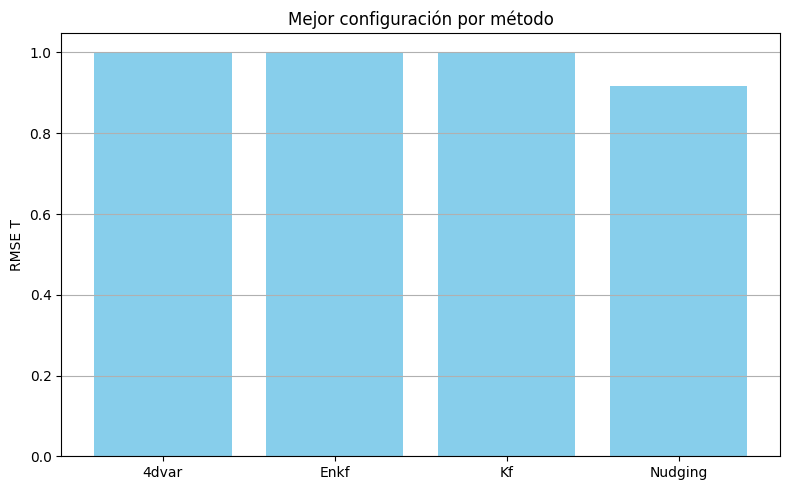

                                   archivo   metodo n_sensores  n_frames_obs  \
0   4dvar_25x25_sens20_frames10_varspt.pkl    4dvar       None          6000   
1    enkf_25x25_sens10_frames5_varsptt.pkl     Enkf       None          6000   
2      kf_25x25_sens20_frames20_varspt.pkl       Kf       None          6000   
3  nudging_25x25_sens10_frames5_varspt.pkl  Nudging       None           301   

  variables_asimiladas    rmse_t  
0               [p, T]  0.998670  
1            [p, T, T]  0.998738  
2               [p, T]  0.998695  
3               [p, T]  0.917234  


In [21]:
# Cargar referencia
with open("sim_separacion/800x800.pkl", "rb") as f:
    ref_data = pickle.load(f)

# Interpolar referencia a 25x25
ref_interp = ref_data.copy()
ref_interp["T_history"] = interpolar_referencia(ref_data, nx_objetivo=25, ny_objetivo=25, variable="T")

# Ejecutar análisis
df_resultados = analizar_resultados_asimilacion(
    carpeta_resultados="DA/25x25",
    ref_data=ref_interp,
    variable="T"
)

# Obtener mejores configuraciones
mejores_df = obtener_mejores_resultados_por_metodo(df_resultados, variable="T")
graficar_mejores_por_metodo(mejores_df, variable="T")

# Mostrar tabla de mejores configuraciones
print(mejores_df)


In [22]:
def verificar_frames_guardados(carpeta, variable='T_history', esperado=300):
    errores = []
    
    for archivo in os.listdir(carpeta):
        if archivo.endswith('.pkl'):
            ruta = os.path.join(carpeta, archivo)
            with open(ruta, 'rb') as f:
                datos = pickle.load(f)

            frames = len(datos.get(variable, []))
            if frames != esperado:
                errores.append((archivo, frames))
    
    if errores:
        print("⚠️ Archivos con número incorrecto de frames:")
        for archivo, n in errores:
            print(f" - {archivo}: {n} frames (esperado: {esperado})")
    else:
        print(f"✅ Todos los archivos en '{carpeta}' tienen {esperado} frames en '{variable}'.")

# Usar la función
verificar_frames_guardados("DA/25x25", variable="T_history", esperado=300)


⚠️ Archivos con número incorrecto de frames:
 - enkf_25x25_sens10_frames5_varsptt.pkl: 6000 frames (esperado: 300)
 - nudging_25x25_sens20_frames5_varspt.pkl: 301 frames (esperado: 300)
 - kf_25x25_sens10_frames5_varsptt.pkl: 6000 frames (esperado: 300)
 - kf_25x25_sens5_frames5_varspt.pkl: 6000 frames (esperado: 300)
 - kf_25x25_sens10_frames10_varsptt.pkl: 6000 frames (esperado: 300)
 - nudging_25x25_sens5_frames5_varst.pkl: 301 frames (esperado: 300)
 - 4dvar_25x25_sens20_frames10_varsptt.pkl: 6000 frames (esperado: 300)
 - enkf_25x25_sens10_frames10_varsptt.pkl: 6000 frames (esperado: 300)
 - enkf_25x25_sens10_frames10_varstt.pkl: 6000 frames (esperado: 300)
 - nudging_25x25_sens5_frames10_varst.pkl: 301 frames (esperado: 300)
 - nudging_25x25_sens20_frames10_varspt.pkl: 301 frames (esperado: 300)
 - kf_25x25_sens10_frames10_varstt.pkl: 6000 frames (esperado: 300)
 - 4dvar_25x25_sens5_frames10_varsptt.pkl: 6000 frames (esperado: 300)
 - enkf_25x25_sens20_frames20_varspt.pkl: 6000 f

In [23]:
def verificar_frames_multiples_variables(carpeta, variables=None, esperado=300):
    """
    Verifica que todos los archivos .pkl en la carpeta contengan la misma
    cantidad de frames para las variables especificadas.
    
    Parámetros:
    -----------
    carpeta : str
        Carpeta donde se encuentran los archivos .pkl.
    variables : list of str
        Lista de nombres de variables a verificar. Ej: ["T_history", "p_history"]
    esperado : int
        Número esperado de frames por variable.
    """
    if variables is None:
        variables = ["T_history", "p_history", "tau_history", "u_history", "v_history"]

    errores = []

    for archivo in os.listdir(carpeta):
        if not archivo.endswith(".pkl"):
            continue

        ruta = os.path.join(carpeta, archivo)
        with open(ruta, 'rb') as f:
            datos = pickle.load(f)

        for var in variables:
            if var in datos:
                n = len(datos[var])
                if n != esperado:
                    errores.append((archivo, var, n))
            else:
                errores.append((archivo, var, "❌ No existe"))

    if errores:
        print("⚠️ Inconsistencias encontradas:")
        for archivo, var, n in errores:
            print(f" - {archivo} | {var}: {n} frames (esperado: {esperado})")
    else:
        print(f"✅ Todos los archivos tienen {esperado} frames para las variables {variables}.")

# 🧪 Ejecutar en tu carpeta
verificar_frames_multiples_variables("DA/25x25", esperado=300)


⚠️ Inconsistencias encontradas:
 - enkf_25x25_sens10_frames5_varsptt.pkl | T_history: 6000 frames (esperado: 300)
 - enkf_25x25_sens10_frames5_varsptt.pkl | p_history: 6000 frames (esperado: 300)
 - enkf_25x25_sens10_frames5_varsptt.pkl | tau_history: 6000 frames (esperado: 300)
 - enkf_25x25_sens10_frames5_varsptt.pkl | u_history: 6000 frames (esperado: 300)
 - enkf_25x25_sens10_frames5_varsptt.pkl | v_history: 6000 frames (esperado: 300)
 - nudging_25x25_sens20_frames5_varspt.pkl | T_history: 301 frames (esperado: 300)
 - nudging_25x25_sens20_frames5_varspt.pkl | p_history: 301 frames (esperado: 300)
 - nudging_25x25_sens20_frames5_varspt.pkl | tau_history: 301 frames (esperado: 300)
 - nudging_25x25_sens20_frames5_varspt.pkl | u_history: 301 frames (esperado: 300)
 - nudging_25x25_sens20_frames5_varspt.pkl | v_history: 301 frames (esperado: 300)
 - kf_25x25_sens10_frames5_varsptt.pkl | T_history: 6000 frames (esperado: 300)
 - kf_25x25_sens10_frames5_varsptt.pkl | p_history: 6000 fr